In [3]:
!python3 -m pip install mysql-connector-python sqlalchemy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 38.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 42.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 46.4 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 56.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [pandas]2m6/7 [pandas]emy]ctor-python]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [2]:
!python3 -m pip install mysql-connector-python

In [3]:
import sys
print(sys.executable)

/opt/anaconda3/bin/python


In [7]:
!{sys.executable} -m pip install mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 37.9 MB/s  0:00:00 eta 0:00:01


In [8]:
import mysql.connector as sql

conn = sql.connect(
    host="localhost",
    user="root",
    password="",
    database="cap4770"
)

print(conn.is_connected())

True


In [9]:
import pandas as pd

pd.read_sql("SHOW TABLES", conn)

/var/folders/f7/58bdmmmd29q37zf5wkxqn3q40000gn/T/ipykernel_35090/884095768.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SHOW TABLES", conn)


,Tables_in_cap4770
0,train


In [10]:
from sqlalchemy import create_engine
import pandas as pd

engine = create_engine("mysql+mysqlconnector://root:@localhost/cap4770")

df_csv = pd.read_csv("/Users/luismadrigal/Downloads/archive/train.csv")

print(df_csv.shape)  # should be ~46244

df_csv.to_sql("train", con=engine, if_exists="replace", index=False)

(46244, 25)


46244

In [12]:
pd.read_sql("SELECT COUNT(*) AS total_rows FROM train", engine)

,total_rows
0,46244


In [13]:
df_test = pd.read_csv("/Users/luismadrigal/Downloads/archive/test.csv")

print(df_test.shape)

df_test.to_sql("test", con=engine, if_exists="replace", index=False)

(65779, 24)


65779

In [14]:
df_park = pd.read_csv("/Users/luismadrigal/Downloads/archive/park_dimensions.csv")

print(df_park.shape)

df_park.to_sql("park_dimensions", con=engine, if_exists="replace", index=False)

(30, 9)


30

In [15]:
pd.read_sql("SHOW TABLES", engine)

,Tables_in_cap4770
0,park_dimensions
1,test
2,train


In [16]:
df_train = pd.read_sql("SELECT * FROM train", engine)

In [17]:
df_test = pd.read_sql("SELECT * FROM test", engine)

In [18]:
df_park = pd.read_sql("SELECT * FROM park_dimensions", engine)

In [19]:
print(df_train.shape)
print(df_test.shape)
print(df_park.shape)

(46244, 25)
(65779, 24)
(30, 9)


In [20]:
df_total = pd.concat([df_train, df_test], ignore_index=True)

In [21]:
print(df_total.shape)
df_total.head()

(112023, 25)


,bip_id,game_date,home_team,away_team,batter_team,batter_name,pitcher_name,batter_id,pitcher_id,is_batter_lefty,...,inning,outs_when_up,balls,strikes,plate_x,plate_z,pitch_mph,launch_speed,launch_angle,is_home_run
0,1,2020-08-26,ARI,COL,COL,"arenado, nolan","ray, robbie",571448,592662,0,...,1,0,1,2,-0.15,1.97,87.8,108.9,9.0,0.0
1,2,2020-08-10,COL,ARI,COL,"arenado, nolan","ray, robbie",571448,592662,0,...,1,1,3,1,-0.71,2.88,95.2,NaN,18.0,0.0
2,3,2020-08-10,COL,ARI,COL,"arenado, nolan","ray, robbie",571448,592662,0,...,3,0,1,2,-0.54,1.75,86.5,75.0,49.0,0.0
3,4,2020-08-26,ARI,COL,COL,"blackmon, charlie","ray, robbie",453568,592662,1,...,1,0,0,2,-0.42,3.15,86.7,90.6,54.0,0.0
4,5,2020-08-10,COL,ARI,COL,"blackmon, charlie","ray, robbie",453568,592662,1,...,1,1,1,0,0.18,3.27,96.1,NaN,6.0,0.0


In [23]:
df_park.head()

,park,NAME,Cover,LF_Dim,CF_Dim,RF_Dim,LF_W,CF_W,RF_W
0,0,Chase Field,Roof,328,407,335,8,25,8
1,1,SunTrust Park,Outdoor,335,400,325,6,8,16
2,2,Oriole Park at Camden Yards,Outdoor,333,400,318,7,7,21
3,3,Fenway Park,Outdoor,310,390,302,37,9,3
4,4,Wrigley Field,Outdoor,355,400,353,16,11,16


In [24]:
df_train.to_csv("train_clean.csv", index=False)
df_test.to_csv("test_clean.csv", index=False)
df_park.to_csv("park_dimensions_clean.csv", index=False)
df_total.to_csv("df_total.csv", index=False)

In [25]:
import os
os.getcwd()

'/Users/luismadrigal/anaconda_projects/07dd458b-3d25-40a6-b564-b12287d7cedd'

In [27]:
df_test.head()

,bip_id,game_date,home_team,away_team,batter_team,batter_name,pitcher_name,batter_id,pitcher_id,is_batter_lefty,...,park,inning,outs_when_up,balls,strikes,plate_x,plate_z,pitch_mph,launch_speed,launch_angle
0,16,2021-06-23 00:00:00,MIA,TOR,MIA,"marte, starling","ray, robbie",516782,592662,0,...,14,6,0,2,1,-0.09,2.10,87.6,109.0,22.0
1,17,2021-06-23 00:00:00,MIA,TOR,MIA,"marte, starling","ray, robbie",516782,592662,0,...,14,1,1,1,2,0.67,1.71,88.4,25.5,NaN
2,18,2021-06-01 00:00:00,TOR,MIA,MIA,"marte, starling","ray, robbie",516782,592662,0,...,28,5,2,0,0,-0.50,2.61,89.1,94.2,NaN
3,19,2021-06-01 00:00:00,TOR,MIA,MIA,"marte, starling","ray, robbie",516782,592662,0,...,28,3,2,2,1,-0.45,1.78,90.4,83.1,NaN
4,32,2021-06-13 00:00:00,BOS,TOR,BOS,"hernandez, enrique","ray, robbie",571771,592662,0,...,3,5,2,0,0,0.26,2.29,90.1,108.1,NaN


In [28]:
df_train = pd.read_sql("SELECT * FROM train", engine)

In [30]:
data = df_train
data.duplicated().sum()
print(data.shape)
data.isna().sum()

(46244, 25)


bip_id                  0
game_date               0
home_team               0
away_team               0
batter_team             0
batter_name             0
pitcher_name            0
batter_id               0
pitcher_id              0
is_batter_lefty         0
is_pitcher_lefty        0
bb_type                 6
bearing                 0
pitch_name              0
park                    0
inning                  0
outs_when_up            0
balls                   0
strikes                 0
plate_x                 0
plate_z                 0
pitch_mph               0
launch_speed        11805
launch_angle        11785
is_home_run             0
dtype: int64

In [31]:
bball_model = data.dropna(subset=["launch_speed", "launch_angle"]).copy()

bball_model["bb_type"] = bball_model["bb_type"].fillna("Unknown")

In [32]:
print(bball_model.shape)
bball_model.isna().sum()

(25866, 25)


bip_id              0
game_date           0
home_team           0
away_team           0
batter_team         0
batter_name         0
pitcher_name        0
batter_id           0
pitcher_id          0
is_batter_lefty     0
is_pitcher_lefty    0
bb_type             0
bearing             0
pitch_name          0
park                0
inning              0
outs_when_up        0
balls               0
strikes             0
plate_x             0
plate_z             0
pitch_mph           0
launch_speed        0
launch_angle        0
is_home_run         0
dtype: int64

In [34]:
bball_model = data.dropna(subset=["launch_speed", "launch_angle"]).copy()
bball_model["bb_type"] = bball_model["bb_type"].fillna("Unknown")

for col in bball_model.columns:
    if bball_model[col].nunique() <= 1:
        bball_model = bball_model.drop(columns=[col])

cols_to_drop = ["bip_id", "batter_id", "pitcher_id", "batter_name", "pitcher_name"]
bball_model = bball_model.drop(columns=cols_to_drop, errors="ignore")

X = bball_model.drop(columns=["is_home_run"])
y = bball_model["is_home_run"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
data.head()
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46244 entries, 0 to 46243
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   bip_id            46244 non-null  int64  
 1   game_date         46244 non-null  object 
 2   home_team         46244 non-null  object 
 3   away_team         46244 non-null  object 
 4   batter_team       46244 non-null  object 
 5   batter_name       46244 non-null  object 
 6   pitcher_name      46244 non-null  object 
 7   batter_id         46244 non-null  int64  
 8   pitcher_id        46244 non-null  int64  
 9   is_batter_lefty   46244 non-null  int64  
 10  is_pitcher_lefty  46244 non-null  int64  
 11  bb_type           46238 non-null  object 
 12  bearing           46244 non-null  object 
 13  pitch_name        46244 non-null  object 
 14  park              46244 non-null  int64  
 15  inning            46244 non-null  int64  
 16  outs_when_up      46244 non-null  int64 

,bip_id,batter_id,pitcher_id,is_batter_lefty,is_pitcher_lefty,park,inning,outs_when_up,balls,strikes,plate_x,plate_z,pitch_mph,launch_speed,launch_angle,is_home_run
count,46244.000000,46244.00000,46244.000000,46244.000000,46244.000000,46244.000000,46244.000000,46244.000000,46244.000000,46244.000000,46244.000000,46244.000000,46244.000000,34439.000000,34459.000000,46244.000000
mean,61886.135693,585994.82229,592001.279993,0.421071,0.273419,14.423709,4.830097,0.960860,1.124124,1.107884,-0.005890,2.323522,88.860602,88.038189,12.477263,0.052915
std,37002.379194,65617.97127,65743.959401,0.493736,0.445719,8.672130,2.523844,0.818038,1.017073,0.808433,0.542757,0.571431,5.924192,14.791351,28.890217,0.223866
min,1.000000,405395.00000,424144.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-2.060000,-0.140000,70.000000,7.500000,-89.000000,0.000000
25%,27981.000000,543592.00000,545064.000000,0.000000,0.000000,7.000000,3.000000,0.000000,0.000000,0.000000,-0.390000,1.930000,84.700000,79.700000,-5.000000,0.000000
50%,64002.500000,596129.00000,605525.000000,0.000000,0.000000,14.000000,5.000000,1.000000,1.000000,1.000000,-0.010000,2.310000,89.700000,90.900000,13.000000,0.000000
75%,94694.500000,642082.00000,643290.000000,1.000000,1.000000,22.000000,7.000000,2.000000,2.000000,2.000000,0.380000,2.720000,93.600000,99.000000,31.000000,0.000000
max,119520.000000,680777.00000,685493.000000,1.000000,1.000000,29.000000,13.000000,2.000000,3.000000,2.000000,2.200000,4.740000,102.800000,118.400000,90.000000,1.000000


In [36]:
corr_matrix = data.corr(numeric_only=True)
corr_matrix

,bip_id,batter_id,pitcher_id,is_batter_lefty,is_pitcher_lefty,park,inning,outs_when_up,balls,strikes,plate_x,plate_z,pitch_mph,launch_speed,launch_angle,is_home_run
bip_id,1.000000,0.037723,-0.014333,-0.013866,0.009507,-0.047973,0.058626,0.003746,0.011892,-0.002493,0.010955,0.005578,-0.075954,0.013894,-0.007721,0.010680
batter_id,0.037723,1.000000,-0.004120,0.001368,0.004676,0.015760,0.010128,-0.012997,0.003953,0.008792,-0.010780,-0.008769,-0.009631,-0.010486,-0.022710,0.001247
pitcher_id,-0.014333,-0.004120,1.000000,0.017636,-0.028759,-0.026735,-0.025624,0.002063,0.006641,-0.000568,-0.013314,0.017487,0.122665,0.009070,0.000915,0.006060
is_batter_lefty,-0.013866,0.001368,0.017636,1.000000,-0.167445,-0.003583,-0.006380,-0.009630,0.027046,0.009496,-0.121256,-0.017705,0.022419,-0.022963,-0.003804,-0.015527
is_pitcher_lefty,0.009507,0.004676,-0.028759,-0.167445,1.000000,0.010359,-0.057838,-0.008725,0.008328,0.006236,0.071787,-0.001313,-0.145044,-0.021782,-0.016621,-0.001313
park,-0.047973,0.015760,-0.026735,-0.003583,0.010359,1.000000,-0.009862,0.001545,0.005980,0.001848,-0.003562,0.005362,-0.000670,0.002011,0.000035,-0.004843
inning,0.058626,0.010128,-0.025624,-0.006380,-0.057838,-0.009862,1.000000,0.001597,-0.013123,-0.005748,-0.007223,0.010945,0.053831,-0.006699,-0.006006,-0.020142
outs_when_up,0.003746,-0.012997,0.002063,-0.009630,-0.008725,0.001545,0.001597,1.000000,0.014832,-0.003163,0.000716,-0.022347,0.005874,0.000277,-0.000169,-0.011835
balls,0.011892,0.003953,0.006641,0.027046,0.008328,0.005980,-0.013123,0.014832,1.000000,0.403989,0.005130,-0.006764,0.083133,0.063073,0.027358,0.017501
strikes,-0.002493,0.008792,-0.000568,0.009496,0.006236,0.001848,-0.005748,-0.003163,0.403989,1.000000,0.033017,-0.033492,-0.066390,-0.032572,-0.019771,-0.034292


In [37]:
cov_matrix = data.cov(numeric_only=True)
cov_matrix

,bip_id,batter_id,pitcher_id,is_batter_lefty,is_pitcher_lefty,park,inning,outs_when_up,balls,strikes,plate_x,plate_z,pitch_mph,launch_speed,launch_angle,is_home_run
bip_id,1.369176e+09,9.159162e+07,-3.486781e+07,-253.325092,156.798873,-15394.167285,5474.952363,113.380525,447.545577,-74.583699,220.016115,117.941185,-16649.840840,7591.459435,-8244.978989,88.468351
batter_id,9.159162e+07,4.305718e+09,-1.777326e+07,44.322867,136.747701,8968.344723,1677.291087,-697.640846,263.809399,466.386342,-383.924817,-328.820687,-3743.854890,-10181.528698,-43027.576889,18.317277
pitcher_id,-3.486781e+07,-1.777326e+07,4.322268e+09,572.460804,-842.742193,-15242.936167,-4251.676385,110.942906,444.043203,-30.193692,-475.077417,656.963822,47775.566849,8822.172096,1734.618374,89.186382
is_batter_lefty,-2.533251e+02,4.432287e+01,5.724608e+02,0.243775,-0.036849,-0.015342,-0.007950,-0.003889,0.013582,0.003790,-0.032494,-0.004995,0.065574,-0.167791,-0.054246,-0.001716
is_pitcher_lefty,1.567989e+02,1.367477e+02,-8.427422e+02,-0.036849,0.198665,0.040041,-0.065064,-0.003181,0.003775,0.002247,0.017366,-0.000335,-0.382991,-0.143611,-0.213744,-0.000131
park,-1.539417e+04,8.968345e+03,-1.524294e+04,-0.015342,0.040041,75.205844,-0.215858,0.010962,0.052741,0.012956,-0.016766,0.026570,-0.034436,0.258015,0.008713,-0.009403
inning,5.474952e+03,1.677291e+03,-4.251676e+03,-0.007950,-0.065064,-0.215858,6.369787,0.003297,-0.033686,-0.011728,-0.009895,0.015786,0.804873,-0.249937,-0.437819,-0.011380
outs_when_up,1.133805e+02,-6.976408e+02,1.109429e+02,-0.003889,-0.003181,0.010962,0.003297,0.669186,0.012341,-0.002092,0.000318,-0.010446,0.028469,0.003355,-0.003984,-0.002167
balls,4.475456e+02,2.638094e+02,4.440432e+02,0.013582,0.003775,0.052741,-0.033686,0.012341,1.034438,0.332174,0.002832,-0.003931,0.500903,0.949463,0.803662,0.003985
strikes,-7.458370e+01,4.663863e+02,-3.019369e+01,0.003790,0.002247,0.012956,-0.011728,-0.002092,0.332174,0.653564,0.014487,-0.015472,-0.317963,-0.389266,-0.461749,-0.006206


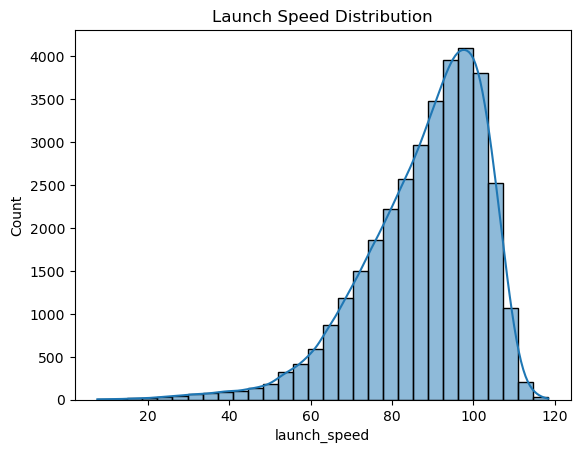

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data["launch_speed"], bins=30, kde=True)
plt.title("Launch Speed Distribution")
plt.show()

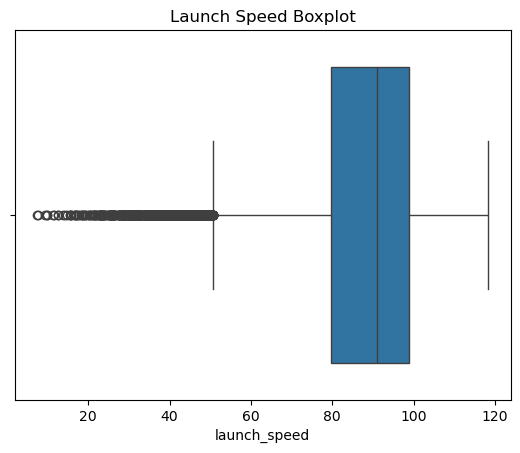

In [39]:
sns.boxplot(x=data["launch_speed"])
plt.title("Launch Speed Boxplot")
plt.show()

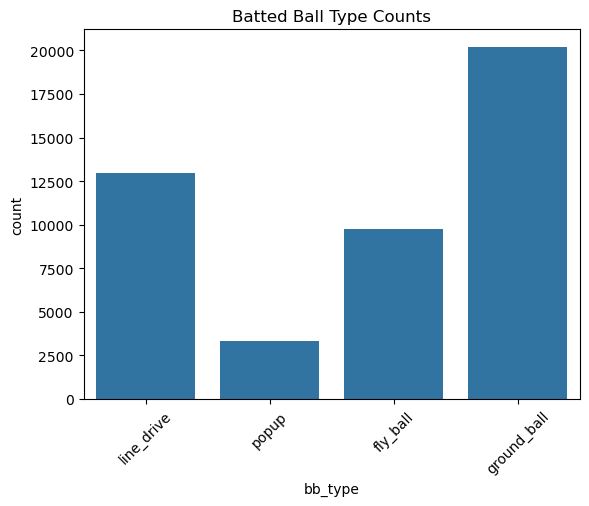

In [40]:
sns.countplot(x="bb_type", data=data)
plt.xticks(rotation=45)
plt.title("Batted Ball Type Counts")
plt.show()

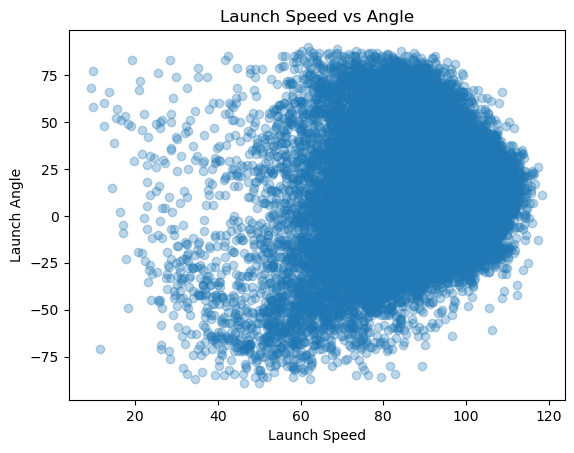

In [41]:
plt.scatter(data["launch_speed"], data["launch_angle"], alpha=0.3)
plt.xlabel("Launch Speed")
plt.ylabel("Launch Angle")
plt.title("Launch Speed vs Angle")
plt.show()

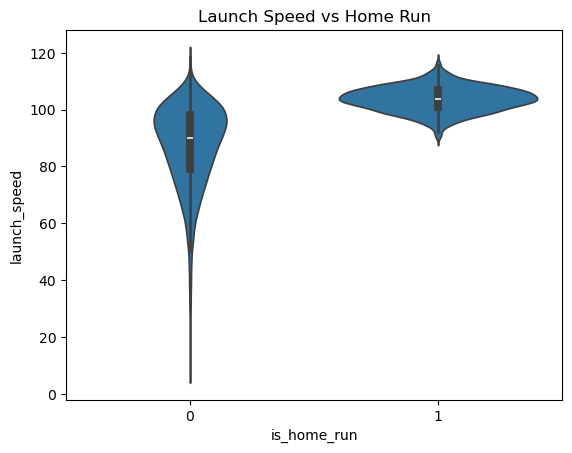

In [42]:
sns.violinplot(x="is_home_run", y="launch_speed", data=data)
plt.title("Launch Speed vs Home Run")
plt.show()

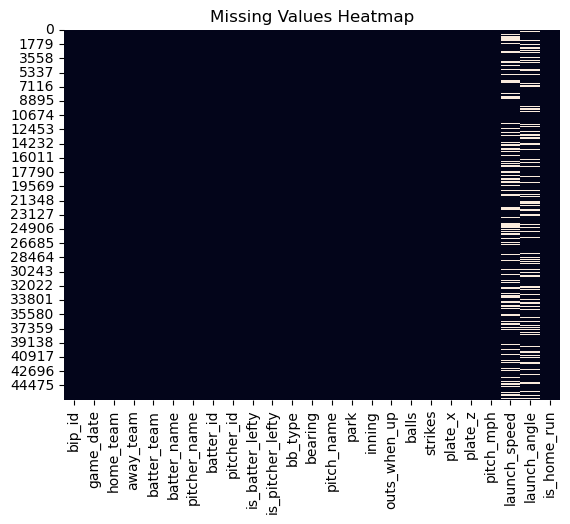

In [43]:
data.isnull().sum()
(data.isnull().sum() / len(data)) * 100
sns.heatmap(data.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

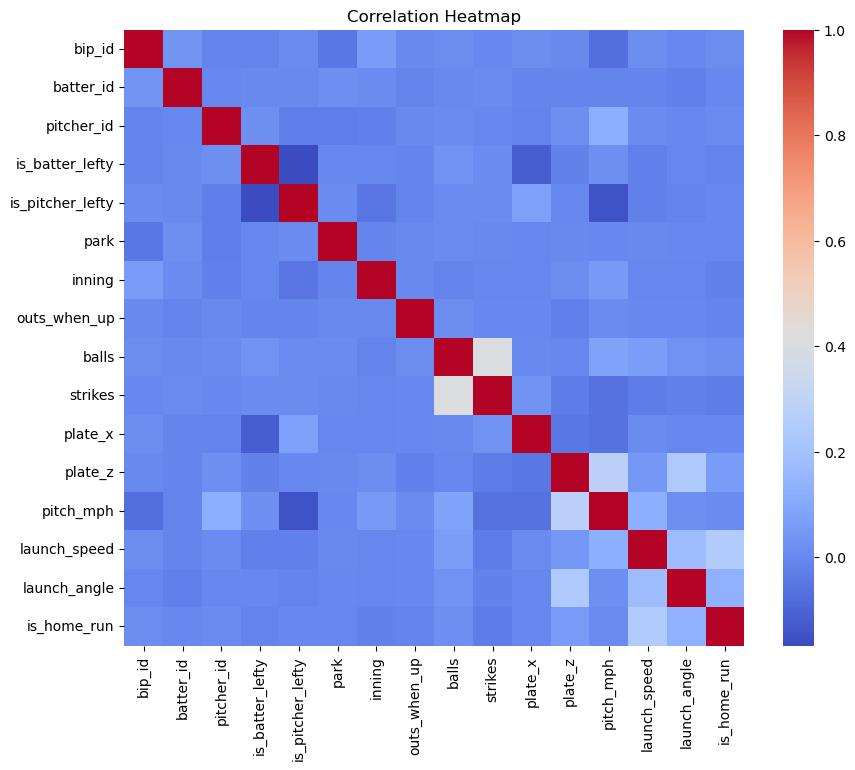

In [44]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

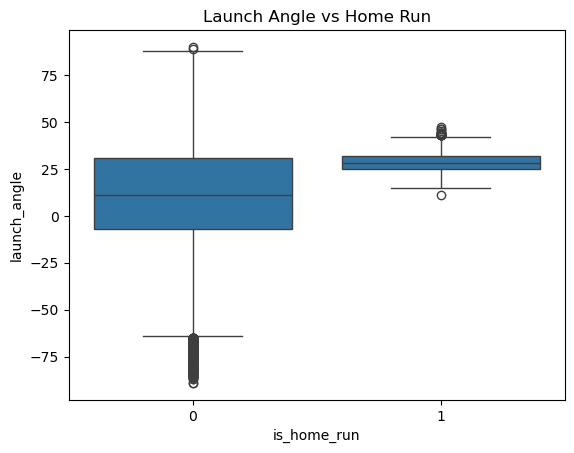

In [45]:
sns.boxplot(x="is_home_run", y="launch_angle", data=data)
plt.title("Launch Angle vs Home Run")
plt.show()

In [56]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_model.fit(X_train_scaled, y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [49]:
y_pred = svm_model.predict(X_test_scaled)

In [50]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix

array([[6750,  613],
       [ 150,  247]])

In [51]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.9016752577319588

In [52]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.92      0.95      7363
           1       0.29      0.62      0.39       397

    accuracy                           0.90      7760
   macro avg       0.63      0.77      0.67      7760
weighted avg       0.94      0.90      0.92      7760



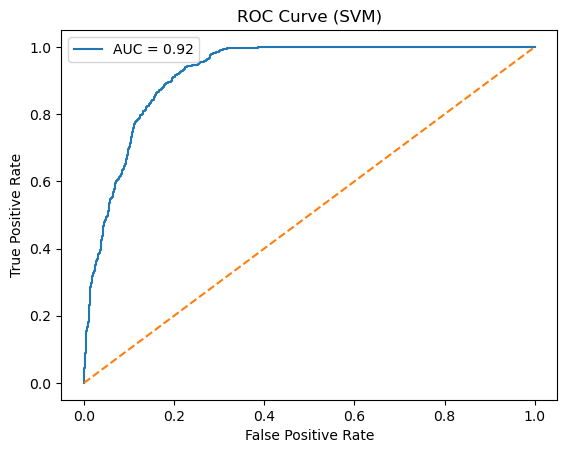

In [55]:
from sklearn.metrics import roc_curve, auc

y_scores = svm_model.decision_function(X_test_scaled)

fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

import matplotlib.pyplot as plt

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (SVM)")
plt.legend()
plt.show()

In [54]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=5)

print("CV Scores:", scores)
print("Mean CV:", scores.mean())

CV Scores: [0.9006074  0.90389395 0.90858879 0.90030378 0.89864678]
Mean CV: 0.9024081409887199
